In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('dataset.csv')

# Display the first 5 rows to understand the data structure
display(df.head())

,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0


In [2]:
# Define severity bins based on UEFA consensus
def classify_severity(days_missed):
    if 1 <= days_missed <= 7:
        return 'minimal'
    elif 8 <= days_missed <= 28:
        return 'moderate'
    elif days_missed > 28:
        return 'severe'
    else:
        return 'unknown' # Handle cases where days_missed might be 0 or negative

# Apply the classification to create a new 'severity' column
df['severity'] = df['days_missed'].apply(classify_severity)

# Display the count of each severity category to verify
display(df['severity'].value_counts())

# Display the first few rows with the new 'severity' column
display(df.head())

,count
severity,
severe,48914
moderate,37436
minimal,10618


,player_id,injury_code,age_at_injury,height,position_code,total_prior_injuries,days_since_last_injury,same_site_reinjury,days_since_same_site_injury,days_missed,severity
0,2,0,27.0,186.0,2,0,-1.0,0,-1.0,27.0,moderate
1,3,1,31.0,180.0,2,0,-1.0,0,-1.0,19.0,moderate
2,5,2,34.0,184.0,1,0,-1.0,0,-1.0,22.0,moderate
3,5,3,34.0,184.0,1,1,75.0,0,-1.0,5.0,minimal
4,6,3,35.0,190.0,0,0,-1.0,0,-1.0,5.0,minimal


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Drop 'player_id' as it's an identifier and not a feature
# Also drop 'days_missed' as 'severity' is derived from it
X = df.drop(['player_id', 'days_missed', 'severity'], axis=1)
y = df['severity']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Handle potential missing values by filling with the mean for numerical columns
# (Though looking at df.head(), there might be -1 values which could be placeholders for NaNs)
for col in numerical_features:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())

# Convert target variable 'severity' into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print("Data preparation complete. X_train and y_train are ready for model training.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Severity classes encoded: {list(label_encoder.classes_)}")

Data preparation complete. X_train and y_train are ready for model training.
Shape of X_train: (67877, 8)
Shape of X_test: (29091, 8)
Severity classes encoded: ['minimal', 'moderate', 'severe']


In [4]:
# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Model Training and Evaluation Complete.")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Model Training and Evaluation Complete.
Accuracy: 0.5324

Classification Report:
              precision    recall  f1-score   support

     minimal       0.21      0.06      0.09      3208
    moderate       0.47      0.49      0.48     11294
      severe       0.59      0.67      0.63     14589

    accuracy                           0.53     29091
   macro avg       0.43      0.41      0.40     29091
weighted avg       0.50      0.53      0.51     29091



### Model Performance Summary

The Random Forest model has been successfully trained and evaluated. Here's a summary of the performance:

*   **Overall Accuracy:** The model achieved an accuracy of approximately **53.24%** on the test set.

*   **Classification Report:**
    *   For **minimal** injuries, the model has low precision (0.21) and recall (0.06), indicating it struggles to correctly identify these cases. This suggests that a significant portion of actual minimal injuries are misclassified as other severities, and among those predicted as minimal, only 21% are truly minimal.
    *   For **moderate** injuries, the performance is better with a precision of 0.47 and recall of 0.49. This means about half of the actual moderate injuries are correctly identified, and nearly half of what the model predicts as moderate are indeed moderate.
    *   For **severe** injuries, the model shows the best performance with a precision of 0.59 and recall of 0.67, suggesting it is more effective at predicting severe injuries. This indicates that the model is reasonably good at identifying severe injuries and most of its severe predictions are correct.

This shows that while the model has some predictive power, there is room for improvement, especially in distinguishing 'minimal' severity injuries. The class imbalance might be a contributing factor to the lower performance in the 'minimal' category.

# Confusion Matrix

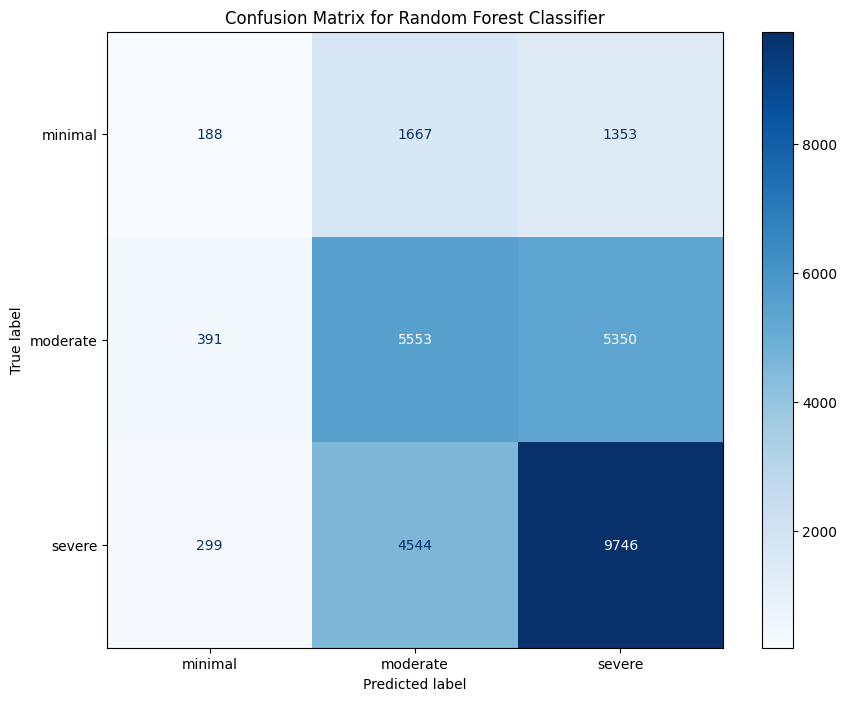

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Random Forest Classifier')
plt.show()